In [1]:
# Math & Data manipulation
import numpy as np
import pandas as pd
import scipy as sp
import statsmodels.api as sm
import sympy as sym
import pooch

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotnine

# Single-cell analysis
import scanpy as sc
import anndata as ad

# Machine Learning & Deep Learning
import scvi
import sklearn
import torch
import scgpt

/Users/melinariepl/miniforge3/envs/ramming/lib/python3.14/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
/Users/melinariepl/miniforge3/envs/ramming/lib/python3.14/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed


In [2]:
adata = sc.read_h5ad("data/adata_subsampled.h5ad")

In [3]:
print(adata)

AnnData object with n_obs × n_vars = 52200 × 30172
    obs: 'library_uuid', 'assay_ontology_term_id', 'mapped_reference_annotation', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'cell_state', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_state', 'suspension_enriched_cell_types', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'sex_ontology_term_id', 'Processing_Cohort', 'ct_cov', 'ind_cov', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ensembl_id'
    uns: 'citation', 'default_embedding', 'is_pre_analysis', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_umap'
    layers: None (.X)


In [4]:
# QC

# MT genes: MT-, mt-, or Mt-
adata.var["mt"] = adata.var_names.str.contains(r"^MT-|^mt-", regex=True)

# Ribosomal genes: RPL/RPS or rpl/rps followed by digits or letters
adata.var["ribo"] = adata.var_names.str.contains(r"^RP[SL]|^rp[sl]", regex=True)

# Hemoglobin genes: HBA, HBB, HBD, HBG, HBE, etc. (excludes non-globin HBP1, HBS1L)
adata.var["hb"] = adata.var_names.str.contains(r"^HB[^(P|S)]|^Hb[^(p|s)]", regex=True)

# Calculate QC metrics across all cells and genes
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

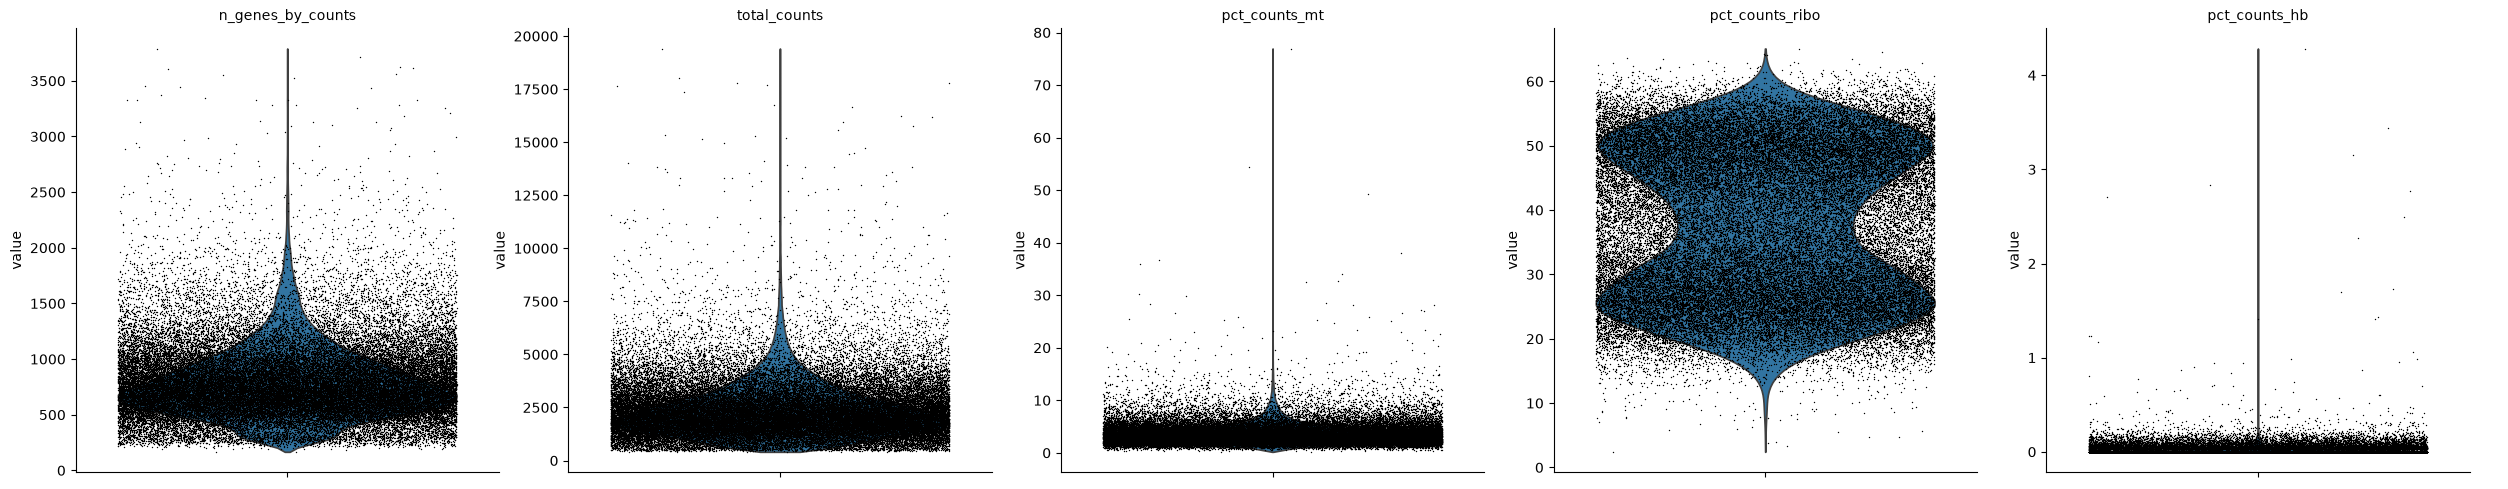

In [5]:
# Violin plots of key metrics
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)


In [6]:

min_genes = 300
max_genes = 6000
min_counts = 800
max_counts = 35000
max_mt = 15.0
max_hb = 1.0

cell_mask = (
    (adata.obs["n_genes_by_counts"] >= min_genes)
    & (adata.obs["n_genes_by_counts"] <= max_genes)
    & (adata.obs["total_counts"] >= min_counts)
    & (adata.obs["total_counts"] <= max_counts)
    & (adata.obs["pct_counts_mt"] <= max_mt)
    & (adata.obs["pct_counts_hb"] <= max_hb)
)

print(f"Cells passing QC: {cell_mask.sum():,} / {adata.n_obs:,} ({cell_mask.mean() * 100:.1f}%)")
adata = adata[cell_mask].copy()
print(f"Remaining dataset shape after QC: {adata.n_obs:,} cells × {adata.n_vars:,} genes")

min_cell_pct = 0.001  # e.g., expressed in at least 0.1% of cells (or 0.005 for 0.5%)
min_cells_threshold = int(np.ceil(min_cell_pct * adata.n_obs))
sc.pp.filter_genes(adata, min_cells=min_cells_threshold)
print(f"Kept genes detected in >= {min_cells_threshold} cells ({min_cell_pct * 100:.2f}% of total cells).")


Cells passing QC: 49,444 / 52,200 (94.7%)
Remaining dataset shape after QC: 49,444 cells × 30,172 genes
Kept genes detected in >= 50 cells (0.10% of total cells).


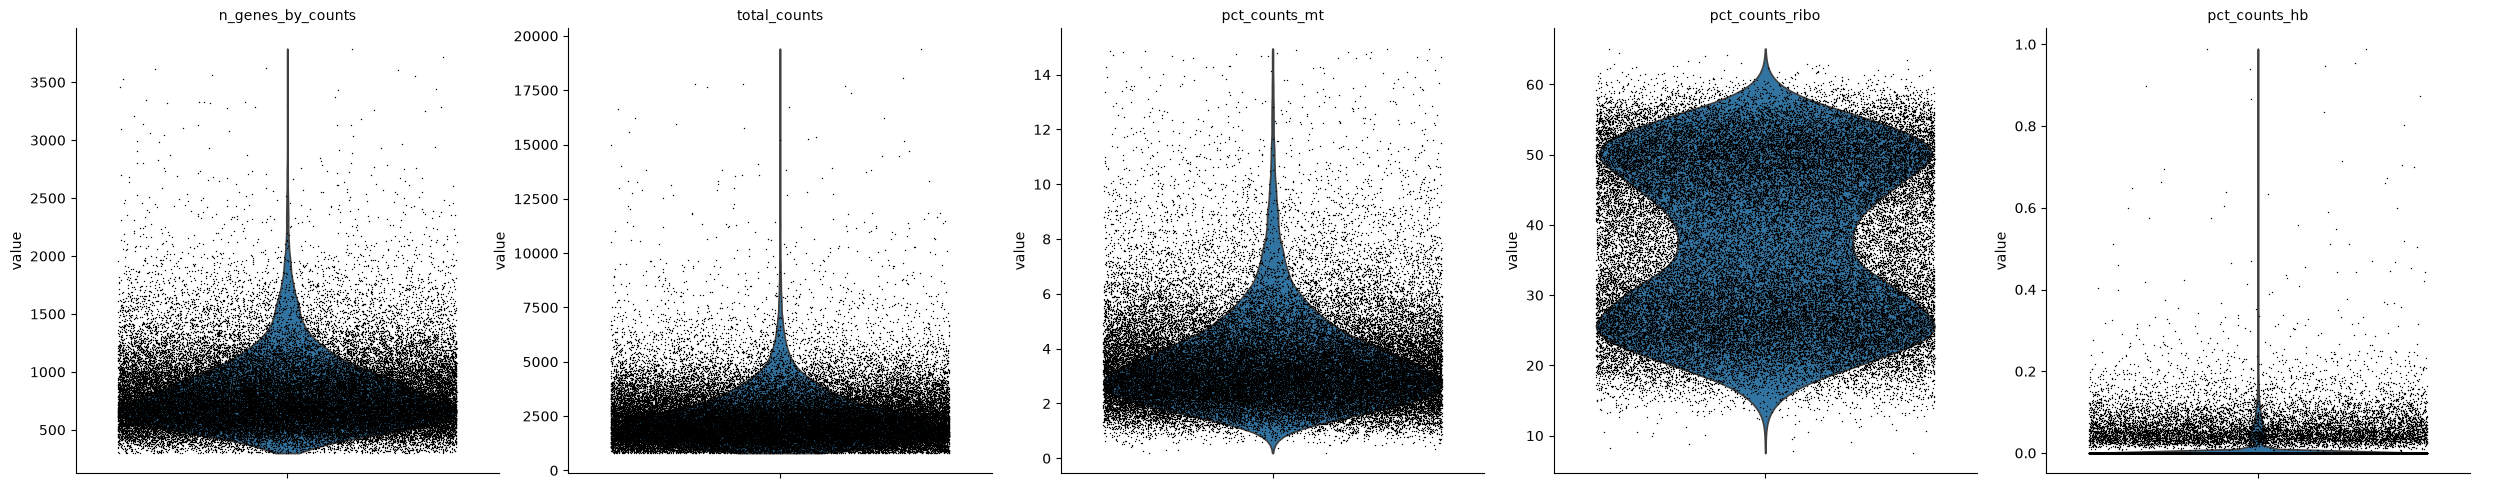

In [7]:
# Violin plots of key metrics
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)


In [8]:
# Normalisation
# 1. Preserve integer raw counts in .layers for downstream tools (e.g., scVI, differential expression)
adata.layers["counts"] = adata.X.copy()

# 2. Total-count normalization (scales counts per cell to 10,000 / CP10K)
sc.pp.normalize_total(adata, target_sum=1e4)

# 3. Log-transform (computes ln(1 + x))
sc.pp.log1p(adata)

In [9]:
# HVG
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    subset=True,  # Change if necessary
    layer="counts",
    flavor="seurat_v3"
)
## Scale (adata.X becomes z-scores)
# sc.pp.scale(adata, max_value=10)


In [10]:
sc.tl.pca(adata)

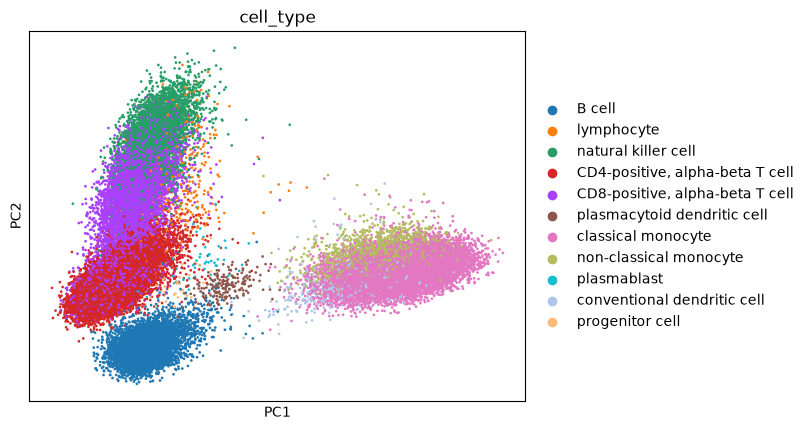

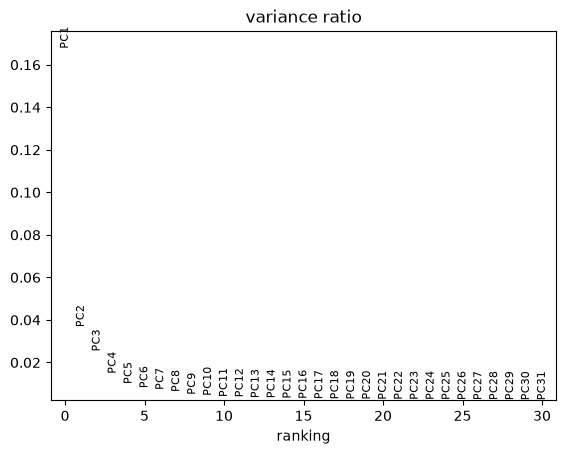

In [11]:
# Color by sample/batch covariates or cell types
sc.pl.pca(
    adata,
    color=["cell_type"],
    components=["1,2"],  # Plots PC1 vs PC2
    ncols=2,
    size=15,
)

# Plot variance explained per PC (Elbow / Scree plot)
sc.pl.pca_variance_ratio(adata, n_pcs=30, log=False)

In [12]:
# one batch-integration method

# 2. scvi will now only initialize the neural net for those ~2000 genes
scvi.model.SCVI.setup_anndata(
    adata, layer="counts", batch_key="library_uuid"
)


In [ ]:
model = scvi.model.SCVI(adata)
model.train(early_stopping=True)

/Users/melinariepl/miniforge3/envs/ramming/lib/python3.14/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/melinariepl/miniforge3/envs/ramming/lib/python3.14/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/melinariepl/miniforge3/envs/ramming/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is 

Training:   0%|          | 0/162 [00:00<?, ?it/s]

In [ ]:
adata.obsm["X_scVI"] = model.get_latent_representation()

In [ ]:
# Compute neighbors and UMAP for pca
sc.pp.neighbors(adata, use_rep="X_pca", key_added="pca")
sc.tl.umap(adata, neighbors_key="pca")
adata.obsm["X_umap_pca"] = adata.obsm["X_umap"].copy()

In [ ]:
# Compute neighbors and UMAP for scvi
sc.pp.neighbors(adata, use_rep="X_scVI", key_added="scvi")
sc.tl.umap(adata, neighbors_key="scvi")
adata.obsm["X_umap_scvi"] = adata.obsm["X_umap"].copy()

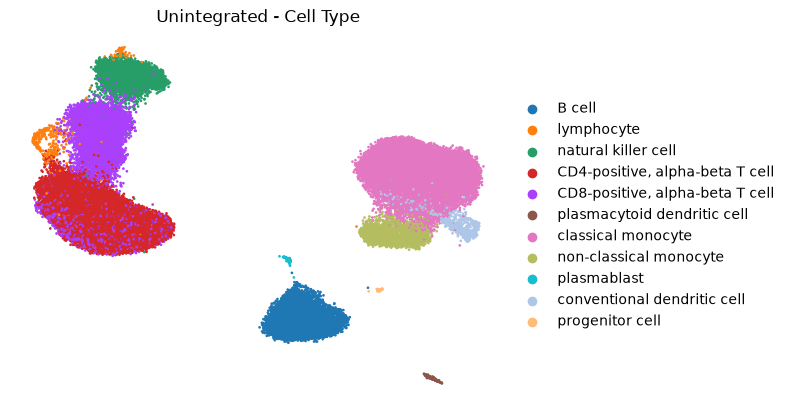

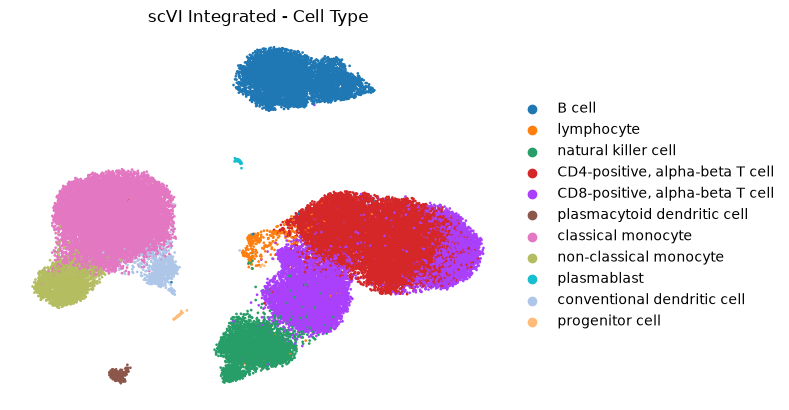

In [ ]:
batch_key = "donor_id" 

# --- Unintegrated (PCA) ---
sc.pl.embedding(
    adata,
    basis="X_umap_pca",
    color=["cell_type"],
    title=["Unintegrated - Cell Type"],
    ncols=2,
    size=15,
    frameon=False,
)

# --- Integrated (scVI) ---
sc.pl.embedding(
    adata,
    basis="X_umap_scvi",
    color=["cell_type"],
    title=["scVI Integrated - Cell Type"],
    ncols=2,
    size=15,
    frameon=False,
)

In [ ]:
adata.write_h5ad("data/adata_integrated.h5ad")
model.save("data/", overwrite=True)